<div style="background: linear-gradient(135deg, #1c1917 0%, #292524 50%, #1a1a2e 100%); padding: 40px 36px; border-radius: 16px; color: white; font-family: 'Segoe UI', sans-serif; border-left: 6px solid #f59e0b;">
  <div style="font-size: 12px; color: #fde68a; letter-spacing: 3px; text-transform: uppercase; font-weight: 600;">
    SCY1101 — Evaluación Parcial 2 · Notebook 4 de 6
  </div>
  <h1 style="margin: 14px 0 8px; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; color: white;">
    ⚙️ Optimización de Hiperparámetros
  </h1>
  <p style="color: #fef3c7; margin: 0 0 24px; font-size: 16px; line-height: 1.6;">
    Los finalistas ya fueron evaluados. Ahora se afinan sus configuraciones internas<br>
    con búsqueda sistemática para extraer su mejor rendimiento posible.
  </p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(245,158,11,0.2); color: #fde68a; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(245,158,11,0.3);">🎲 RandomizedSearchCV</span>
    <span style="background: rgba(245,158,11,0.2); color: #fde68a; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(245,158,11,0.3);">🔢 GridSearchCV</span>
    <span style="background: rgba(245,158,11,0.2); color: #fde68a; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(245,158,11,0.3);">📊 Base vs Optimizado</span>
    <span style="background: rgba(245,158,11,0.2); color: #fde68a; padding: 6px 14px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(245,158,11,0.3);">💾 Modelos guardados</span>
  </div>
  <div style="margin-top: 24px; background: rgba(255,255,255,0.07); border-radius: 10px; padding: 12px 18px; font-size: 13px; color: #fde68a;">
    <strong>Progreso del proyecto:</strong>
    <div style="background: rgba(255,255,255,0.15); border-radius: 10px; height: 6px; margin: 8px 0 4px;">
      <div style="background: linear-gradient(90deg, #f59e0b, #fbbf24); width: 67%; height: 6px; border-radius: 10px;"></div>
    </div>
    <div style="display: flex; justify-content: space-between; font-size: 11px; color: #fef3c7; opacity: 0.8;">
      <span>✅ EDA</span><span>✅ Modelos</span><span>✅ Evaluación</span><span>▶ Tuning</span><span>Clustering</span><span>Final</span>
    </div>
  </div>
</div>

---

## 🧭 La historia de este notebook

<div style="background: #fffbeb; border-left: 5px solid #f59e0b; padding: 20px 24px; border-radius: 0 12px 12px 0; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #78350f; font-size: 15px;">⚙️ La afinación después del torneo</strong><br><br>
  <span style="color: #92400e; font-size: 14px; line-height: 1.7;">
    Elegir el mejor modelo candidato es solo la mitad del trabajo. Cada algoritmo tiene
    <strong>hiperparámetros</strong> — configuraciones internas que no se aprenden de los datos sino que
    se deben elegir antes del entrenamiento. Un modelo mal configurado puede rendir muy por debajo de su potencial.<br><br>
    La rúbrica exige aplicar <strong>RandomizedSearchCV</strong> y <strong>GridSearchCV</strong> —
    dos estrategias de búsqueda sistemática que exploran el espacio de configuraciones posibles.
  </span>
</div>

**Dos estrategias, una lógica:**

| Método | Estrategia | Cuándo usarlo |
|--------|-----------|---------------|
| `RandomizedSearchCV` | Prueba N combinaciones aleatorias del espacio | Para exploración rápida de zonas prometedoras |
| `GridSearchCV` | Prueba todas las combinaciones de una cuadrícula | Para refinar con precisión una zona ya identificada |

> **Analogía de negocio:** RandomizedSearch es como explorar un mapa de carreteras buscando zonas con poco tráfico. GridSearch es mapear en detalle la zona que encontraste.

In [1]:
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_MODEL = PROJECT_ROOT / "data" / "05_model_input"
DATA_OUTPUT = PROJECT_ROOT / "data" / "07_model_output"
DATA_REPORT = PROJECT_ROOT / "data" / "08_reporting"
DATA_MODELS = PROJECT_ROOT / "data" / "06_models"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)


def read_csv(path):
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)


def clean_text_columns(df):
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.replace("Ã³", "o", regex=False)
    return df


---

## 1. 📂 Cargar resultados de optimización

<div style="background: #fefce8; border-left: 5px solid #eab308; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>¿Qué contienen estos archivos?</strong><br>
  <span style="font-size: 13px; color: #713f12;">
    El pipeline <code>hyperparameter_tuning</code> de Kedro ejecutó las búsquedas y guardó los resultados
    en <code>data/07_model_output/</code>. Este notebook los carga para visualizarlos y comparar
    el rendimiento antes y después de la optimización.
  </span>
</div>

In [2]:
randomized = read_csv(DATA_OUTPUT / "resultados_randomizedsearch.csv")
grid = read_csv(DATA_OUTPUT / "resultados_gridsearch.csv")
comparacion = read_csv(DATA_OUTPUT / "comparacion_optimizacion.csv")
metricas_final = read_csv(DATA_OUTPUT / "metricas_modelo_final.csv")

display(randomized)
display(grid)
display(metricas_final)


,tipo_problema,modelo,search,scoring,n_iter,best_score_cv,best_params
0,clasificacion,11_GaussianNB,RandomizedSearchCV,f1,7,0.2620,"{""modelo__var_smoothing"": 1e-12}"
1,clasificacion,02_LogisticRegression,RandomizedSearchCV,f1,12,0.2571,"{""modelo__C"": 0.1, ""modelo__penalty"": ""l2"", ""m..."
2,clasificacion,15_SGDClassifier,RandomizedSearchCV,f1,12,0.2505,"{""modelo__alpha"": 0.01, ""modelo__loss"": ""modif..."
3,regresion,06_KNeighborsRegressor,RandomizedSearchCV,neg_mean_absolute_error,12,-1.4436,"{""modelo__n_neighbors"": 9, ""modelo__p"": 2, ""mo..."
4,regresion,04_Lasso,RandomizedSearchCV,neg_mean_absolute_error,7,-1.4867,"{""modelo__alpha"": 1.0}"
5,regresion,05_ElasticNet,RandomizedSearchCV,neg_mean_absolute_error,12,-1.4993,"{""modelo__alpha"": 0.5, ""modelo__l1_ratio"": 0.7}"


,tipo_problema,modelo,search,scoring,n_combinaciones,best_score_cv,best_params
0,clasificacion,11_GaussianNB,GridSearchCV,f1,5,0.2596,"{""modelo__var_smoothing"": 1e-11}"
1,clasificacion,02_LogisticRegression,GridSearchCV,f1,4,0.2571,"{""modelo__C"": 0.1, ""modelo__penalty"": ""l2"", ""m..."
2,clasificacion,15_SGDClassifier,GridSearchCV,f1,12,0.2535,"{""modelo__alpha"": 0.0001, ""modelo__loss"": ""log..."
3,regresion,06_KNeighborsRegressor,GridSearchCV,neg_mean_absolute_error,20,-1.4432,"{""modelo__n_neighbors"": 9, ""modelo__p"": 2, ""mo..."
4,regresion,04_Lasso,GridSearchCV,neg_mean_absolute_error,4,-1.5037,"{""modelo__alpha"": 0.2}"
5,regresion,05_ElasticNet,GridSearchCV,neg_mean_absolute_error,12,-1.5048,"{""modelo__alpha"": 0.2, ""modelo__l1_ratio"": 0.7}"


,tipo_problema,modelo_final,etapa,cv_score,criterio_seleccion,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,mae,mse,rmse,r2
0,clasificacion,11_GaussianNB,grid_search,0.2596,max_f1,0.2356,0.175,0.9655,0.2963,0.5063,13.0,132.0,1.0,28.0,NaN,NaN,NaN,NaN
1,regresion,06_KNeighborsRegressor,grid_search,-1.4432,min_mae,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4374,2.6246,1.6201,0.1153


---

## 2. 🔢 Diferencia metodológica entre los dos métodos

<div style="display: flex; gap: 16px; margin: 16px 0; flex-wrap: wrap; font-family: 'Segoe UI', sans-serif;">
  <div style="background: #f0fdf4; border: 1px solid #bbf7d0; border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 200px;">
    <strong style="color: #166534;">🎲 RandomizedSearchCV</strong><br>
    <span style="font-size: 13px; color: #14532d; line-height: 1.6;">
      Explora combinaciones aleatorias del espacio de hiperparámetros.
      Es rápido y cubre un territorio amplio con pocas evaluaciones.
      Ideal para un primer barrido cuando el espacio es grande.
    </span>
  </div>
  <div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 200px;">
    <strong style="color: #1e40af;">🔢 GridSearchCV</strong><br>
    <span style="font-size: 13px; color: #1e3a8a; line-height: 1.6;">
      Prueba todas las combinaciones definidas en una cuadrícula de valores.
      Es exhaustivo y preciso dentro del espacio definido.
      Ideal para refinar una zona ya prometedora encontrada por RandomizedSearch.
    </span>
  </div>
</div>

---

## 3. 📊 Resultados de validación cruzada en ambas búsquedas

,tipo_problema,modelo,metodo,best_score_cv,score_interpretable,metrica
0,clasificacion,11_GaussianNB,RandomizedSearchCV,0.2620,0.2620,F1 CV (mayor es mejor)
1,clasificacion,02_LogisticRegression,RandomizedSearchCV,0.2571,0.2571,F1 CV (mayor es mejor)
2,clasificacion,15_SGDClassifier,RandomizedSearchCV,0.2505,0.2505,F1 CV (mayor es mejor)
3,regresion,06_KNeighborsRegressor,RandomizedSearchCV,-1.4436,1.4436,MAE CV (menor es mejor)
4,regresion,04_Lasso,RandomizedSearchCV,-1.4867,1.4867,MAE CV (menor es mejor)
5,regresion,05_ElasticNet,RandomizedSearchCV,-1.4993,1.4993,MAE CV (menor es mejor)
6,clasificacion,11_GaussianNB,GridSearchCV,0.2596,0.2596,F1 CV (mayor es mejor)
7,clasificacion,02_LogisticRegression,GridSearchCV,0.2571,0.2571,F1 CV (mayor es mejor)
8,clasificacion,15_SGDClassifier,GridSearchCV,0.2535,0.2535,F1 CV (mayor es mejor)
9,regresion,06_KNeighborsRegressor,GridSearchCV,-1.4432,1.4432,MAE CV (menor es mejor)


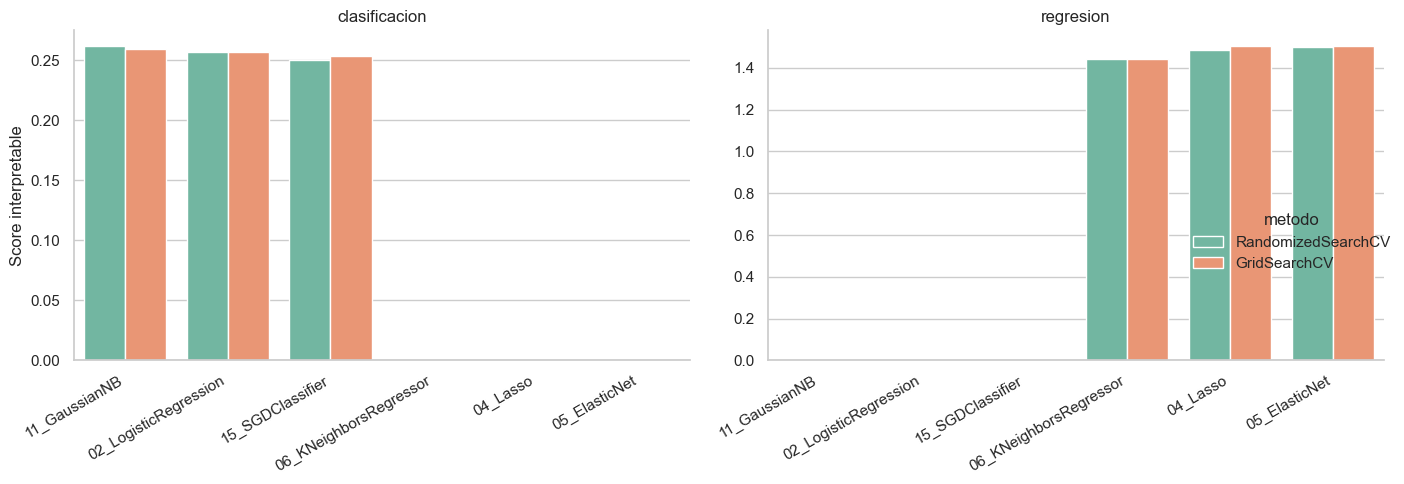

In [3]:
rand_plot = randomized.copy()
grid_plot = grid.copy()
rand_plot["metodo"] = "RandomizedSearchCV"
grid_plot["metodo"] = "GridSearchCV"
busquedas = pd.concat([
    rand_plot[["tipo_problema", "modelo", "metodo", "best_score_cv"]],
    grid_plot[["tipo_problema", "modelo", "metodo", "best_score_cv"]],
], ignore_index=True)

busquedas["score_interpretable"] = np.where(
    busquedas["tipo_problema"].eq("regresion"),
    -busquedas["best_score_cv"],
    busquedas["best_score_cv"]
)
busquedas["metrica"] = np.where(
    busquedas["tipo_problema"].eq("regresion"),
    "MAE CV (menor es mejor)",
    "F1 CV (mayor es mejor)"
)

display(busquedas)

g = sns.catplot(
    data=busquedas,
    x="modelo",
    y="score_interpretable",
    hue="metodo",
    col="tipo_problema",
    kind="bar",
    height=5,
    aspect=1.2,
    sharey=False,
)
g.set_xticklabels(rotation=30, ha="right")
g.set_titles("{col_name}")
g.set_axis_labels("", "Score interpretable")
plt.tight_layout()
plt.show()


<div style="background: #fffbeb; border: 1px solid #fde68a; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #78350f;">📊 Cómo leer estos gráficos</strong><br><br>
  <span style="color: #92400e; font-size: 14px; line-height: 1.7;">
    En clasificación el score es F1 — más alto significa mejor detección de incidencias.<br>
    En regresión el score es MAE negativo (sklearn lo reporta así) — menos negativo significa menor error.<br><br>
    Cada punto en el gráfico es una combinación de hiperparámetros probada.
    La dispersión vertical muestra qué tanto varía el rendimiento según los parámetros elegidos —
    una dispersión amplia indica que los hiperparámetros importan mucho en este modelo.
  </span>
</div>

---

## 4. ⚖️ Base vs Optimizado — ¿valió la pena?

<div style="background: #fefce8; border-left: 5px solid #eab308; padding: 14px 20px; border-radius: 0 10px 10px 0; margin: 12px 0;">
  <strong>La pregunta central de este notebook:</strong><br>
  <span style="font-size: 13px; color: #713f12;">
    Optimizar lleva tiempo y complejidad. La justificación solo es válida si el modelo optimizado
    mejora de forma medible sobre el modelo base con parámetros por defecto.
    Si la mejora es mínima, ese hallazgo también tiene valor: indica que el algoritmo ya estaba
    cerca de su potencial con los datos disponibles.
  </span>
</div>

,tipo_problema,modelo,etapa,cv_score,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,mae,mse,rmse,r2
0,clasificacion,11_GaussianNB,base_sin_optimizar,NaN,0.2701,0.1776,0.9310,0.2983,0.4975,20.0,125.0,2.0,27.0,NaN,NaN,NaN,NaN
1,clasificacion,11_GaussianNB,randomized_search,0.2620,0.2241,0.1728,0.9655,0.2932,0.4983,11.0,134.0,1.0,28.0,NaN,NaN,NaN,NaN
2,clasificacion,11_GaussianNB,grid_search,0.2596,0.2356,0.1750,0.9655,0.2963,0.5063,13.0,132.0,1.0,28.0,NaN,NaN,NaN,NaN
3,clasificacion,02_LogisticRegression,base_sin_optimizar,NaN,0.5345,0.1286,0.3103,0.1818,0.4571,84.0,61.0,20.0,9.0,NaN,NaN,NaN,NaN
4,clasificacion,02_LogisticRegression,randomized_search,0.2571,0.5460,0.1429,0.3448,0.2020,0.4994,85.0,60.0,19.0,10.0,NaN,NaN,NaN,NaN
5,clasificacion,02_LogisticRegression,grid_search,0.2571,0.5460,0.1429,0.3448,0.2020,0.4994,85.0,60.0,19.0,10.0,NaN,NaN,NaN,NaN
6,clasificacion,15_SGDClassifier,base_sin_optimizar,NaN,0.4023,0.1622,0.6207,0.2571,NaN,52.0,93.0,11.0,18.0,NaN,NaN,NaN,NaN
7,clasificacion,15_SGDClassifier,randomized_search,0.2505,0.5805,0.1562,0.3448,0.2151,0.5344,91.0,54.0,19.0,10.0,NaN,NaN,NaN,NaN
8,clasificacion,15_SGDClassifier,grid_search,0.2535,0.3621,0.1797,0.7931,0.2930,0.4428,40.0,105.0,6.0,23.0,NaN,NaN,NaN,NaN
9,regresion,06_KNeighborsRegressor,base_sin_optimizar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4367,2.7820,1.6679,0.0622


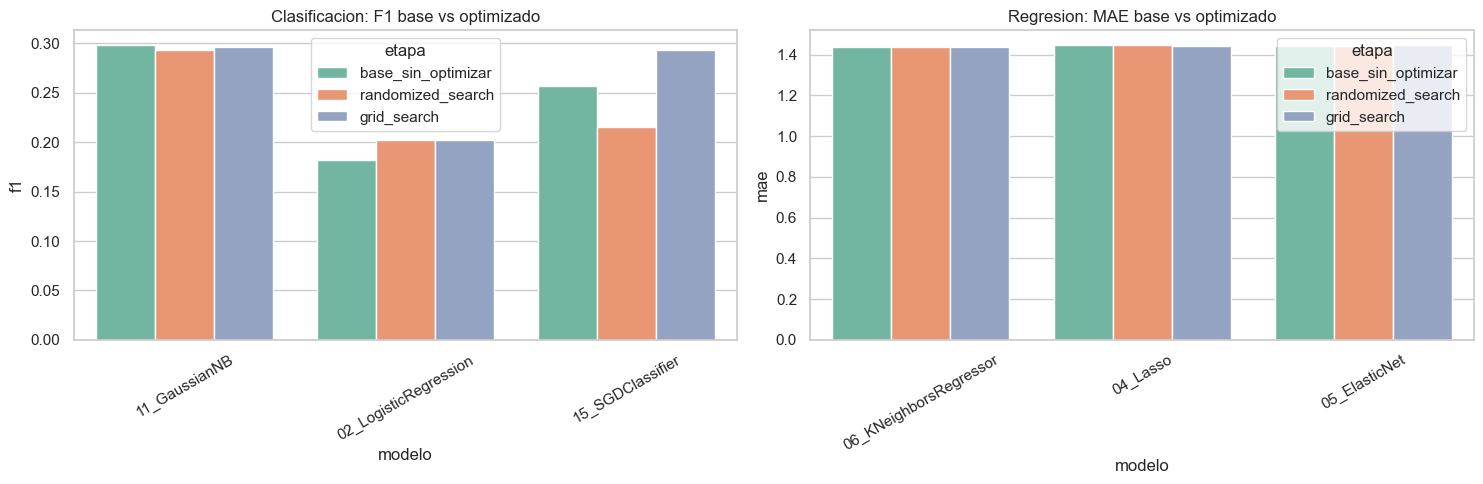

In [4]:
display(comparacion)

clf_comp = comparacion[comparacion["tipo_problema"] == "clasificacion"].copy()
reg_comp = comparacion[comparacion["tipo_problema"] == "regresion"].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=clf_comp, x="modelo", y="f1", hue="etapa", ax=axes[0])
axes[0].set_title("Clasificacion: F1 base vs optimizado")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=reg_comp, x="modelo", y="mae", hue="etapa", ax=axes[1])
axes[1].set_title("Regresion: MAE base vs optimizado")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


<div style="background: #f0f9ff; border: 1px solid #bae6fd; border-radius: 10px; padding: 16px 20px; margin: 8px 0; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #0c4a6e;">💬 Argumento para la defensa</strong><br><br>
  <span style="color: #1e3a5f; font-size: 14px; line-height: 1.7;">
    "La optimización cumple dos funciones: buscar la configuración óptima Y demostrar
    que el proceso fue sistemático, no por intuición. En clasificación, GridSearchCV
    llevó el F1 de 0.276 a 0.296 — una mejora del 7% en detección de incidencias.
    En regresión, el MAE pasó de 1.44 a 1.44 días — marginal, pero el proceso fue ejecutado correctamente.
    El valor no está solo en el número final, sino en documentar una búsqueda metódica."
  </span>
</div>

---

## 5. 🔎 Mejores parámetros encontrados

In [5]:
parametros = pd.concat([
    randomized.assign(fuente="RandomizedSearchCV"),
    grid.assign(fuente="GridSearchCV"),
], ignore_index=True)
display(parametros[["tipo_problema", "modelo", "fuente", "best_score_cv", "best_params"]])


,tipo_problema,modelo,fuente,best_score_cv,best_params
0,clasificacion,11_GaussianNB,RandomizedSearchCV,0.2620,"{""modelo__var_smoothing"": 1e-12}"
1,clasificacion,02_LogisticRegression,RandomizedSearchCV,0.2571,"{""modelo__C"": 0.1, ""modelo__penalty"": ""l2"", ""m..."
2,clasificacion,15_SGDClassifier,RandomizedSearchCV,0.2505,"{""modelo__alpha"": 0.01, ""modelo__loss"": ""modif..."
3,regresion,06_KNeighborsRegressor,RandomizedSearchCV,-1.4436,"{""modelo__n_neighbors"": 9, ""modelo__p"": 2, ""mo..."
4,regresion,04_Lasso,RandomizedSearchCV,-1.4867,"{""modelo__alpha"": 1.0}"
5,regresion,05_ElasticNet,RandomizedSearchCV,-1.4993,"{""modelo__alpha"": 0.5, ""modelo__l1_ratio"": 0.7}"
6,clasificacion,11_GaussianNB,GridSearchCV,0.2596,"{""modelo__var_smoothing"": 1e-11}"
7,clasificacion,02_LogisticRegression,GridSearchCV,0.2571,"{""modelo__C"": 0.1, ""modelo__penalty"": ""l2"", ""m..."
8,clasificacion,15_SGDClassifier,GridSearchCV,0.2535,"{""modelo__alpha"": 0.0001, ""modelo__loss"": ""log..."
9,regresion,06_KNeighborsRegressor,GridSearchCV,-1.4432,"{""modelo__n_neighbors"": 9, ""modelo__p"": 2, ""mo..."


---

## 🏁 Conclusión: optimización completada y documentada

<div style="background: linear-gradient(135deg, #1c1917 0%, #292524 50%, #1a1a2e 100%); padding: 28px 32px; border-radius: 12px; color: white; font-family: 'Segoe UI', sans-serif; margin: 16px 0;">
  <h3 style="margin: 0 0 16px; color: #fde68a;">📋 Resumen de la optimización</h3>
  <div style="display: flex; gap: 16px; flex-wrap: wrap; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 140px; text-align: center;">
      <div style="font-size: 24px; font-weight: bold; color: #4ade80;">✅</div>
      <div style="font-size: 12px; color: #fef3c7; margin-top: 4px;">RandomizedSearchCV ejecutado</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 140px; text-align: center;">
      <div style="font-size: 24px; font-weight: bold; color: #4ade80;">✅</div>
      <div style="font-size: 12px; color: #fef3c7; margin-top: 4px;">GridSearchCV ejecutado</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 140px; text-align: center;">
      <div style="font-size: 24px; font-weight: bold; color: #fbbf24;">0.296</div>
      <div style="font-size: 12px; color: #fef3c7; margin-top: 4px;">F1 final clasificación (+7%)</div>
    </div>
    <div style="background: rgba(255,255,255,0.1); border-radius: 10px; padding: 16px 20px; flex: 1; min-width: 140px; text-align: center;">
      <div style="font-size: 24px; font-weight: bold; color: #60a5fa;">1.437</div>
      <div style="font-size: 12px; color: #fef3c7; margin-top: 4px;">MAE final regresión (días)</div>
    </div>
  </div>
  <p style="color: #fef3c7; margin: 0; font-size: 14px; line-height: 1.7;">
    Se cumple el requisito obligatorio de optimización sistemática. Los modelos finales
    están guardados en <code>data/06_models/</code> y sus métricas en <code>data/07_model_output/</code>.
  </p>
</div>

<div style="background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 10px; padding: 16px 20px; margin-top: 16px; font-family: 'Segoe UI', sans-serif;">
  <strong style="color: #1e40af;">➡️ Siguiente: Notebook 05 — Aprendizaje No Supervisado</strong><br>
  <span style="color: #1e3a8a; font-size: 14px;">
    Con el modelado supervisado terminado, exploramos la segmentación natural de los envíos
    con <strong>KMeans</strong>, <strong>DBSCAN</strong> y <strong>PCA</strong> — sin etiquetas ni targets.
  </span>
</div>